# Lab assignment №1, part 2

This lab assignment consists of several parts. You are supposed to make some transformations, train some models, estimate the quality of the models and explain your results.

Several comments:
* Don't hesitate to ask questions, it's a good practice.
* No private/public sharing, please. The copied assignments will be graded with 0 points.
* Blocks of this lab will be graded separately.

__*This is the second part of the assignment. First and third parts are waiting for you in the same directory.*__

## Part 2. Data preprocessing, model training and evaluation.

### 1. Reading the data
Today we work with the [dataset](https://archive.ics.uci.edu/ml/datasets/Statlog+%28Vehicle+Silhouettes%29), describing different cars for multiclass ($k=4$) classification problem. The data is available below.

In [20]:
# If on colab, uncomment the following lines

! wget https://raw.githubusercontent.com/girafe-ai/ml-course/22f_made/homeworks/lab01_ml_pipeline/car_data.csv

--2024-12-16 23:08:30--  https://raw.githubusercontent.com/girafe-ai/ml-course/22f_made/homeworks/lab01_ml_pipeline/car_data.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 58374 (57K) [text/plain]
Saving to: ‘car_data.csv.3’

car_data.csv.3      100%[===================>]  57.01K  --.-KB/s    in 0.06s   

2024-12-16 23:08:30 (931 KB/s) - ‘car_data.csv.3’ saved [58374/58374]



In [21]:
!pip install pandas

In [22]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

dataset = pd.read_csv('car_data.csv', delimiter=',', header=None)
print(dataset.head(15))
dataset = dataset.values
data = dataset[:, :-1].astype(int)
target = dataset[:, -1]

print(data.shape, target.shape)

X_train, X_test, y_train, y_test = train_test_split(data, target, test_size=0.35)
print(X_train.shape, y_train.shape, X_test.shape, y_test.shape)

    0    1   2    3    4    5   6    7   8   9    10   11   12   13   14  15  \
0    0   95  48   83  178   72  10  162  42  20  159  176  379  184   70   6   
1    1   91  41   84  141   57   9  149  45  19  143  170  330  158   72   9   
2    2  104  50  106  209   66  10  207  32  23  158  223  635  220   73  14   
3    3   93  41   82  159   63   9  144  46  19  143  160  309  127   63   6   
4    4   85  44   70  205  103  52  149  45  19  144  241  325  188  127   9   
5    5  107  57  106  172   50   6  255  26  28  169  280  957  264   85   5   
6    6   97  43   73  173   65   6  153  42  19  143  176  361  172   66  13   
7    7   90  43   66  157   65   9  137  48  18  146  162  281  164   67   3   
8    8   86  34   62  140   61   7  122  54  17  127  141  223  112   64   2   
9    9   93  44   98  197   62  11  183  36  22  146  202  505  152   64   4   
10  10   86  36   70  143   61   9  133  50  18  130  153  266  127   66   2   
11  11   90  34   66  136   55   6  123 

To get some insights about the dataset, `pandas` might be used. The `train` part is transformed to `pd.DataFrame` below.

In [23]:
X_train_pd = pd.DataFrame(X_train)

# First 15 rows of our dataset.
X_train_pd.head(15)

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18
0,387,90,47,85,145,58,9,152,44,19,155,175,345,184,73,4,2,186,197
1,73,73,37,53,111,54,6,126,55,18,128,135,227,147,82,1,15,176,184
2,62,96,40,70,120,50,8,137,50,18,141,162,269,139,80,10,13,183,183
3,550,86,38,58,119,56,4,118,57,17,129,140,208,152,78,9,2,184,186
4,429,84,37,70,145,62,9,136,48,18,134,159,280,140,68,11,9,194,202
5,657,89,45,85,149,59,11,158,43,20,158,177,362,173,75,12,16,183,193
6,245,93,41,75,124,51,7,140,49,18,141,164,284,149,77,5,15,184,185
7,2,104,50,106,209,66,10,207,32,23,158,223,635,220,73,14,9,188,196
8,654,100,47,88,190,60,10,171,38,21,155,186,440,169,59,15,18,201,210
9,19,101,56,100,215,69,10,208,32,24,169,227,651,223,74,6,5,186,193


Methods `describe` and `info` deliver some useful information.

In [24]:
X_train_pd.describe()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18
count,549.000000,549.000000,549.000000,549.000000,549.000000,549.000000,549.000000,549.000000,549.000000,549.000000,549.00000,549.000000,549.000000,549.000000,549.000000,549.000000,549.000000,549.000000,549.000000
mean,424.431694,93.280510,44.550091,81.249545,168.322404,61.754098,8.488160,167.244080,41.309654,20.455373,147.35337,187.001821,431.663024,172.899818,72.438980,6.364299,12.362477,188.967213,195.546448
std,241.768645,8.071397,6.187442,16.019879,33.652581,7.398930,4.534373,32.635884,7.895226,2.515701,14.56194,30.336705,171.629442,32.330171,7.182857,4.844882,8.907356,6.179406,7.442733
min,1.000000,73.000000,33.000000,40.000000,104.000000,48.000000,2.000000,112.000000,26.000000,17.000000,118.00000,130.000000,184.000000,109.000000,59.000000,0.000000,0.000000,176.000000,181.000000
25%,216.000000,87.000000,40.000000,69.000000,139.000000,57.000000,6.000000,146.000000,34.000000,19.000000,136.00000,167.000000,317.000000,147.000000,67.000000,2.000000,5.000000,184.000000,190.000000
50%,427.000000,93.000000,44.000000,78.000000,168.000000,61.000000,8.000000,156.000000,43.000000,20.000000,145.00000,178.000000,362.000000,172.000000,71.000000,6.000000,11.000000,189.000000,197.000000
75%,638.000000,99.000000,49.000000,96.000000,195.000000,65.000000,10.000000,195.000000,46.000000,22.000000,158.00000,214.000000,573.000000,197.000000,76.000000,10.000000,19.000000,193.000000,201.000000
max,845.000000,117.000000,58.000000,112.000000,306.000000,126.000000,55.000000,262.000000,61.000000,28.000000,188.00000,285.000000,987.000000,264.000000,119.000000,22.000000,41.000000,206.000000,211.000000


In [25]:
X_train_pd.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 549 entries, 0 to 548
Data columns (total 19 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   0       549 non-null    int64
 1   1       549 non-null    int64
 2   2       549 non-null    int64
 3   3       549 non-null    int64
 4   4       549 non-null    int64
 5   5       549 non-null    int64
 6   6       549 non-null    int64
 7   7       549 non-null    int64
 8   8       549 non-null    int64
 9   9       549 non-null    int64
 10  10      549 non-null    int64
 11  11      549 non-null    int64
 12  12      549 non-null    int64
 13  13      549 non-null    int64
 14  14      549 non-null    int64
 15  15      549 non-null    int64
 16  16      549 non-null    int64
 17  17      549 non-null    int64
 18  18      549 non-null    int64
dtypes: int64(19)
memory usage: 81.6 KB


### 2. Machine Learning pipeline
Here you are supposed to perform the desired transformations. Please, explain your results briefly after each task.

#### 2.0. Data preprocessing
* Make some transformations of the dataset (if necessary). Briefly explain the transformations

In [ ]:
### YOUR CODE HERE

#### 2.1. Basic logistic regression
* Find optimal hyperparameters for logistic regression with cross-validation on the `train` data (small grid/random search is enough, no need to find the *best* parameters).

* Estimate the model quality with `f1` and `accuracy` scores.
* Plot a ROC-curve for the trained model. For the multiclass case you might use `scikitplot` library (e.g. `scikitplot.metrics.plot_roc(test_labels, predicted_proba)`).

*Note: please, use the following hyperparameters for logistic regression: `multi_class='multinomial'`, `solver='saga'` `tol=1e-3` and ` max_iter=500`.*

In [ ]:
!pip install scipy==1.11.4

In [26]:
import scipy
print(scipy.__version__)

1.11.4


/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:1247: 

accuracy_score 0.7070707070707071
f1_score 0.6943123889595612


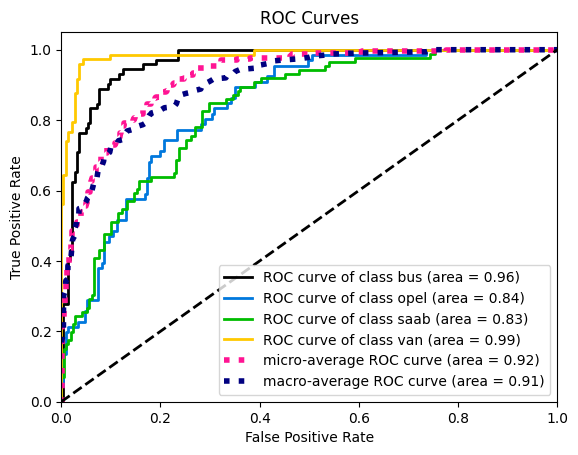

In [32]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score
import scikitplot
import matplotlib.pyplot as plt
from sklearn.model_selection import GridSearchCV

log_reg = LogisticRegression(multi_class='multinomial', solver='saga', tol=1e-3, max_iter=500)

param_grid = {'C': [0.1, 1, 10], 'penalty': ['l1', 'l2']}

grid_search = GridSearchCV(log_reg, param_grid, cv=5)
grid_search.fit(X_train, y_train)

best_log_reg = grid_search.best_estimator_
y_pred = best_log_reg.predict(X_test)

print('accuracy_score', accuracy_score(y_test, y_pred))
print('f1_score', f1_score(y_test, y_pred, average='weighted'))

redicted_proba = best_log_reg.predict_proba(X_test)
scikitplot.metrics.plot_roc(y_test, pred_probas)
plt.show()

#### 2.2. PCA: explained variance plot
* Apply the PCA to the train part of the data. Build the explaided variance plot.

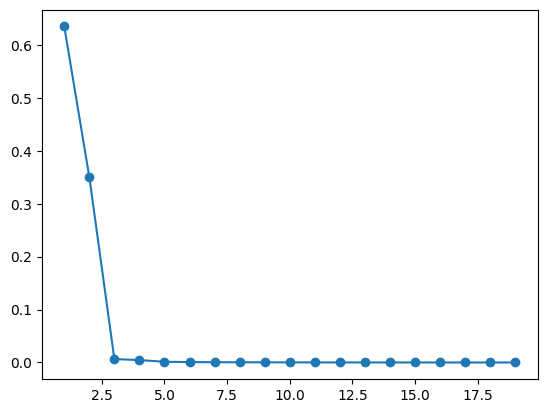

In [28]:
from sklearn.decomposition import PCA

pca = PCA()
X_train_pca = pca.fit_transform(X_train)

explained_variance_ratio = pca.explained_variance_ratio_

plt.plot(range(1, len(explained_variance_ratio) + 1), explained_variance_ratio, marker='o')
plt.show()

#### 2.3. PCA trasformation
* Select the appropriate number of components. Briefly explain your choice. Should you normalize the data?

*Use `fit` and `transform` methods to transform the `train` and `test` parts.*

Метод PCA чувствителен к масштабу признаков, поэтому лучше нормализовать данные

Вообще судя по графику нам достаточно много данных подоходит, около 95 процентов поэтому и возьмем их


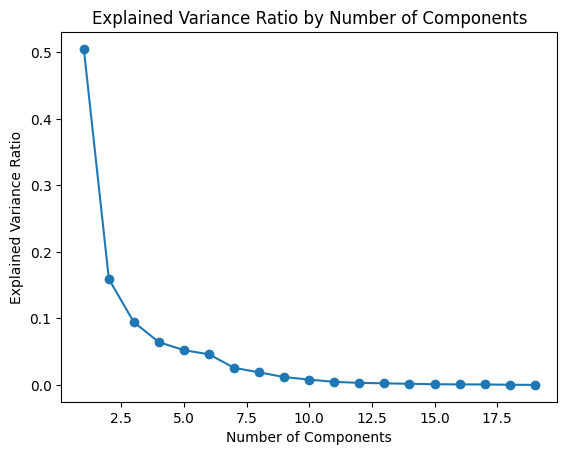

In [29]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

pca = PCA()
X_train_pca = pca.fit_transform(X_train_scaled)

explained_variance_ratio = pca.explained_variance_ratio_

plt.plot(range(1, len(explained_variance_ratio) + 1), explained_variance_ratio, marker='o')
plt.show()

cumulative_variance = np.cumsum(explained_variance_ratio)
num_components = np.argmax(cumulative_variance >= 0.95) + 1

pca = PCA(n_components=num_components)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

**Note: From this point `sklearn` [Pipeline](https://scikit-learn.org/stable/modules/compose.html) might be useful to perform transformations on the data. Refer to the [docs](https://scikit-learn.org/stable/modules/generated/sklearn.pipeline.Pipeline.html) for more information.**

#### 2.4. Logistic regression on PCA-preprocessed data.
* Find optimal hyperparameters for logistic regression with cross-validation on the transformed by PCA `train` data.

* Estimate the model quality with `f1` and `accuracy` scores.
* Plot a ROC-curve for the trained model. For the multiclass case you might use `scikitplot` library (e.g. `scikitplot.metrics.plot_roc(test_labels, predicted_proba)`).

*Note: please, use the following hyperparameters for logistic regression: `multi_class='multinomial'`, `solver='saga'` and `tol=1e-3`*

/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and wi

Accuracy:  0.6464646464646465
F1 Score:  0.6303010854638641


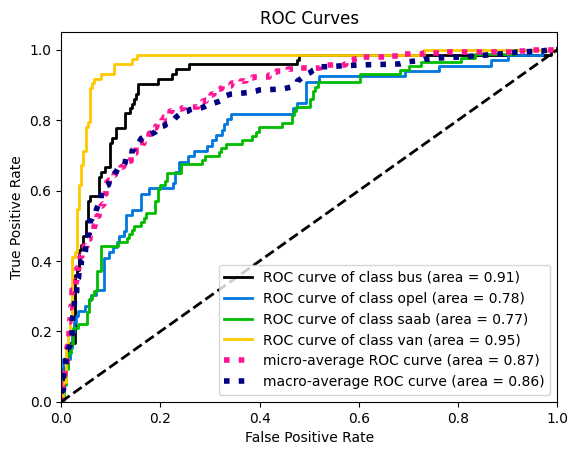

In [33]:
log_reg = LogisticRegression(multi_class='multinomial', solver='saga', tol=1e-3)

param_grid = {'C': [0.1, 1, 10], 'penalty': ['l1', 'l2']}

grid_search = GridSearchCV(log_reg, param_grid, cv=5)
grid_search.fit(X_train_pca, y_train)

best_log_reg = grid_search.best_estimator_

y_pred = best_log_reg.predict(X_test_pca)

accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average='weighted')

print("Accuracy: ", accuracy)
print("F1 Score: ", f1)

predicted_proba = best_log_reg.predict_proba(X_test_pca)
scikitplot.metrics.plot_roc(y_test, predicted_proba)
plt.show()

#### 2.5. Decision tree
* Now train a desicion tree on the same data. Find optimal tree depth (`max_depth`) using cross-validation.

* Measure the model quality using the same metrics you used above.

In [37]:
from sklearn.tree import DecisionTreeClassifier

dt_classifier = DecisionTreeClassifier()

param_grid = {'max_depth': [3, 5, 7, 10]}

grid_search = GridSearchCV(dt_classifier, param_grid, cv=5)
grid_search.fit(X_train_pca, y_train)

best_dt_classifier = grid_search.best_estimator_

y_pred_dt = best_dt_classifier.predict(X_test_pca)

accuracy_dt = accuracy_score(y_test, y_pred_dt)
f1_dt = f1_score(y_test, y_pred_dt, average='weighted')

print("Decision Tree - Accuracy: ", accuracy_dt)
print("Decision Tree - F1 Score: ", f1_dt)

Decision Tree - Accuracy:  0.632996632996633
Decision Tree - F1 Score:  0.6343414093367994


#### 2.6. Bagging.
Here starts the ensembling part.

First we will use the __Bagging__ approach. Build an ensemble of $N$ algorithms varying N from $N_{min}=2$ to $N_{max}=100$ (with step 5).

We will build two ensembles: of logistic regressions and of decision trees.

*Comment: each ensemble should be constructed from models of the same family, so logistic regressions should not be mixed up with decision trees.*


*Hint 1: To build a __Bagging__ ensebmle varying the ensemble size efficiently you might generate $N_{max}$ subsets of `train` data (of the same size as the original dataset) using bootstrap procedure once. Then you train a new instance of logistic regression/decision tree with optimal hyperparameters you estimated before on each subset (so you train it from scratch). Finally, to get an ensemble of $N$ models you average the $N$ out of $N_{max}$ models predictions.*

*Hint 2: sklearn might help you with this taks. Some appropriate function/class might be out there.*

* Plot `f1` and `accuracy` scores plots w.r.t. the size of the ensemble.

* Briefly analyse the plot. What is the optimal number of algorithms? Explain your answer.

* How do you think, are the hyperparameters for the decision trees you found in 2.5 optimal for trees used in ensemble?

/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and wi

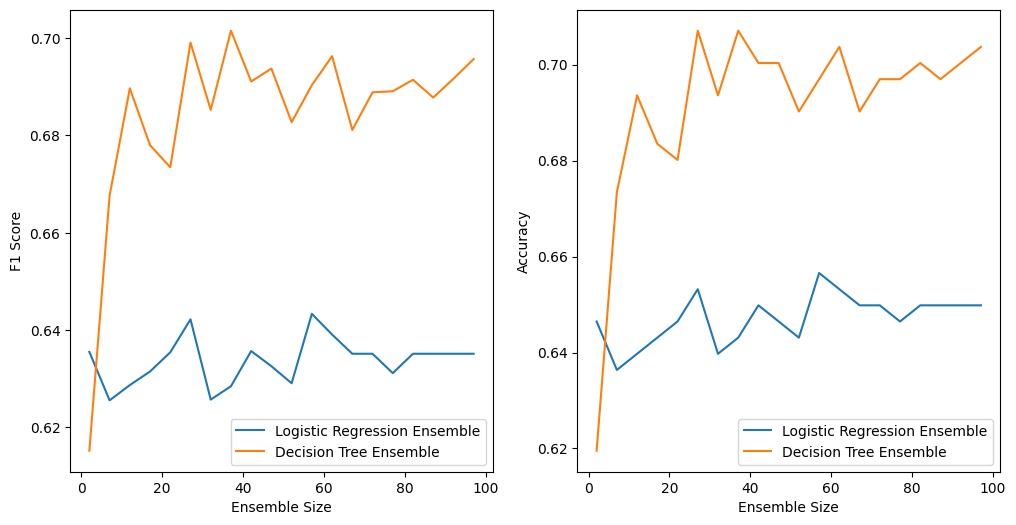

In [40]:
from sklearn.ensemble import BaggingClassifier
import numpy as np

f1_scores_lr = []
f1_scores_dt = []
accuracy_scores_lr = []
accuracy_scores_dt = []

ensemble_sizes = np.arange(2, 101, 5)

for ensemble_size in ensemble_sizes:
    lr_bagging = BaggingClassifier(estimator=best_log_reg, n_estimators=ensemble_size, random_state=42)
    lr_bagging.fit(X_train_pca, y_train)

    dt_bagging = BaggingClassifier(estimator=best_dt_classifier, n_estimators=ensemble_size, random_state=42)
    dt_bagging.fit(X_train_pca, y_train)

    y_pred_lr = lr_bagging.predict(X_test_pca)
    y_pred_dt = dt_bagging.predict(X_test_pca)

    f1_scores_lr.append(f1_score(y_test, y_pred_lr, average='weighted'))
    accuracy_scores_lr.append(accuracy_score(y_test, y_pred_lr))

    f1_scores_dt.append(f1_score(y_test, y_pred_dt, average='weighted'))
    accuracy_scores_dt.append(accuracy_score(y_test, y_pred_dt))

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(ensemble_sizes, f1_scores_lr, label='Logistic Regression Ensemble')
plt.plot(ensemble_sizes, f1_scores_dt, label='Decision Tree Ensemble')
plt.xlabel('Ensemble Size')
plt.ylabel('F1 Score')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(ensemble_sizes, accuracy_scores_lr, label='Logistic Regression Ensemble')
plt.plot(ensemble_sizes, accuracy_scores_dt, label='Decision Tree Ensemble')
plt.xlabel('Ensemble Size')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

В целом у нас получается ансамбль, для логистической регрессии и для дерева решений, как мы видим на графике, из конепции асамблеи лучше себя показывается дерево решений, так аккураси и f1 скор больше.

Все равно кажется что гиперпораметры дерева решений недостаточно, и необходимо далее их понять, чтобы сказать более приближенные оценки

По поводоу оптимальности числа алогритмов, я так понимаю речь про количество алогритмов в ансамбле, на графике показано, что точно должно быть больше 10 оценщиков, чтобы давать хорошую точность, также можно судить по пикам на графике, на них при заданном количество алогритмов в ансамбле была лучшая точность чем при другом количестве. Примерно 26 алогритмов достаточно.

#### 2.7. Random Forest
Now we will work with the Random Forest (its `sklearn` implementation).

* * Plot `f1` and `accuracy` scores plots w.r.t. the number of trees in Random Forest.

* What is the optimal number of trees you've got? Is it different from the optimal number of logistic regressions/decision trees in 2.6? Explain the results briefly.

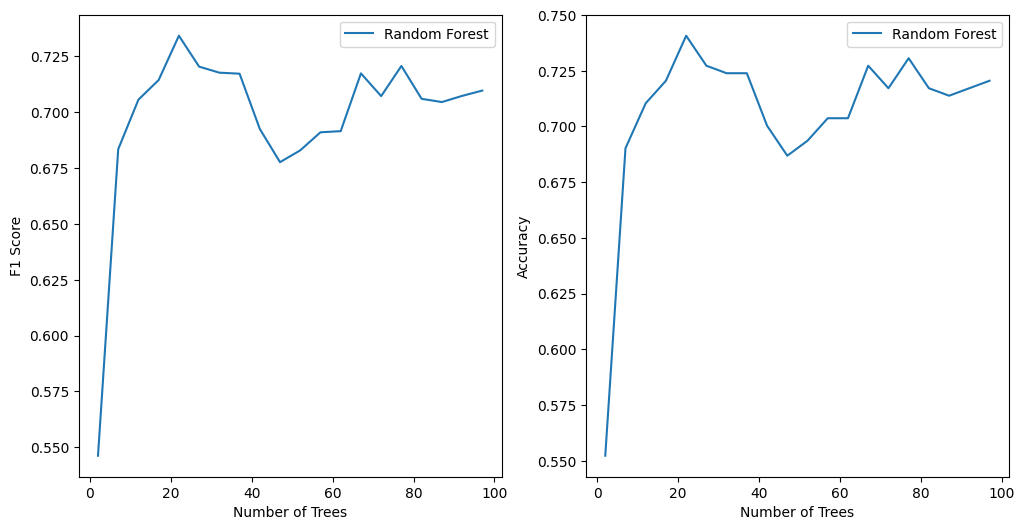

In [44]:
from sklearn.ensemble import RandomForestClassifier

f1_scores_rf = []
accuracy_scores_rf = []

num_trees = np.arange(2, 101, 5)

for n_trees in num_trees:
    rf_classifier = RandomForestClassifier(n_estimators=n_trees, random_state=42)
    rf_classifier.fit(X_train_pca, y_train)

    y_pred_rf = rf_classifier.predict(X_test_pca)

    f1_scores_rf.append(f1_score(y_test, y_pred_rf, average='weighted'))
    accuracy_scores_rf.append(accuracy_score(y_test, y_pred_rf))

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(num_trees, f1_scores_rf, label='Random Forest')
plt.xlabel('Number of Trees')
plt.ylabel('F1 Score')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(num_trees, accuracy_scores_rf, label='Random Forest')
plt.xlabel('Number of Trees')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

Мы взяли то же количество итераций, и видм, что наибольший пик по точности и ф скору наблюдается между 25 и 27, то есть тоже примено 26, как и в случая с ассеамблеем алогритов решающего дерева и логичстической регрессии. То есть в целом очень похоже, по пикам.

#### 2.8. Learning curve
Your goal is to estimate, how does the model behaviour change with the increase of the `train` dataset size.

* Split the training data into 10 equal (almost) parts. Then train the models from above (Logistic regression, Desicion Tree, Random Forest) with optimal hyperparameters you have selected on 1 part, 2 parts (combined, so the train size in increased by 2 times), 3 parts and so on.

* Build a plot of `accuracy` and `f1` scores on `test` part, varying the `train` dataset size (so the axes will be score - dataset size.

* Analyse the final plot. Can you make any conlusions using it?

In [ ]:
# YOUR CODE HERE

#### 2.9. Boosting
Your goal is to build a boosting ensemble using xgboost, CatBoost or lightgbm package.
Please, do not use the sklearn API for these models.

Find optimal number of decision trees in the boosting ensembe using grid search or other methods.
Please, explain your answer.

In [ ]:
# YOUR CODE HERE